In [14]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# List files in the dataset first to find correct file_path
import os
path = kagglehub.dataset_download("brandao/diabetes")
print(os.listdir(path))

['description.pdf', 'diabetic_data.csv']


In [15]:
file_path = "diabetic_data.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "brandao/diabetes",
    file_path,
)

print(df.shape)
df.head()

/tmp/ipykernel_58/883889835.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [18]:
# Cell 4 - Purpose: Inspect columns, dtypes, missing values, and target distribution

print("Columns:\n", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nTarget distribution (readmitted):\n", df['readmitted'].value_counts())

Columns:
 ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Dtypes:
 encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                   

In [19]:
# Cell 5 - Purpose: Replace placeholder "?" with actual NaN, recheck missingness

df = df.replace('?', np.nan)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(missing_summary)

NameError: name 'np' is not defined

In [20]:
# Cell 6 - Purpose: Drop high-missing/non-informative columns, impute categorical missing, binarize target

# Drop columns with too much missingness or no predictive value
cols_to_drop = ['weight', 'payer_code', 'encounter_id', 'patient_nbr']
df = df.drop(columns=cols_to_drop)

# For lab test columns, missingness is clinically meaningful (test not ordered) -> keep as category
df['max_glu_serum'] = df['max_glu_serum'].fillna('Not_tested')
df['A1Cresult'] = df['A1Cresult'].fillna('Not_tested')

# For other categoricals, fill with 'Unknown'
for col in ['race', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].fillna('Unknown')

# Binarize target: readmitted <30 days = 1 (primary clinical concern), else = 0
df['target'] = (df['readmitted'] == '<30').astype(int)
df = df.drop(columns=['readmitted'])

print(df['target'].value_counts(normalize=True))
print(df.shape)

target
0    0.888401
1    0.111599
Name: proportion, dtype: float64
(101766, 46)


In [21]:
# Cell 7 - Purpose: Patient-level train/val/test split to avoid data leakage

# Reload patient_nbr since we need it only for grouping, not as a feature
patient_ids = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "brandao/diabetes",
    "diabetic_data.csv",
)['patient_nbr']

df['patient_nbr'] = patient_ids

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss.split(df, groups=df['patient_nbr']))

train_val_df = df.iloc[train_val_idx]
test_df = df.iloc[test_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=42)  # 0.125 * 0.8 = 0.1 -> 80/10/10
train_idx, val_idx = next(gss2.split(train_val_df, groups=train_val_df['patient_nbr']))

train_df = train_val_df.iloc[train_idx]
val_df = train_val_df.iloc[val_idx]

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)
print("Train target rate:", train_df['target'].mean())
print("Val target rate:", val_df['target'].mean())
print("Test target rate:", test_df['target'].mean())

/tmp/ipykernel_58/1910783870.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  patient_ids = kagglehub.load_dataset(


Train: (71404, 47) Val: (10209, 47) Test: (20153, 47)
Train target rate: 0.11276679177637107
Val target rate: 0.11303751591732784
Test target rate: 0.10673348881059892


In [22]:
# Cell 8 - Purpose: Remove grouping column post-split, separate X and y for each split

train_df = train_df.drop(columns=['patient_nbr'])
val_df = val_df.drop(columns=['patient_nbr'])
test_df = test_df.drop(columns=['patient_nbr'])

X_train, y_train = train_df.drop(columns=['target']), train_df['target']
X_val, y_val = val_df.drop(columns=['target']), val_df['target']
X_test, y_test = test_df.drop(columns=['target']), test_df['target']

print(X_train.shape, X_val.shape, X_test.shape)
print(X_train.dtypes.value_counts())

(71404, 45) (10209, 45) (20153, 45)
object    34
int64     11
Name: count, dtype: int64


In [23]:
# Cell 9 - Purpose: Build preprocessing pipeline - encode categoricals, scale numerics (fit on train only, to prevent leakage)

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
numeric_cols = X_train.select_dtypes(include='int64').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# Fit only on train
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed shapes:", X_train_processed.shape, X_val_processed.shape, X_test_processed.shape)
print("Categorical cols:", len(categorical_cols), "Numeric cols:", len(numeric_cols))

Processed shapes: (71404, 45) (10209, 45) (20153, 45)
Categorical cols: 34 Numeric cols: 11


In [25]:
# Cell 10 - Purpose: Train baseline Logistic Regression as reference model, evaluate on val set

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_processed, y_train)

val_probs = logreg.predict_proba(X_val_processed)[:, 1]
auroc = roc_auc_score(y_val, val_probs)
auprc = average_precision_score(y_val, val_probs)

print(f"Logistic Regression - Val AUROC: {auroc:.4f}, Val AUPRC: {auprc:.4f}")

Logistic Regression - Val AUROC: 0.6280, Val AUPRC: 0.1931


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
# Cell 11 - Purpose: Retrain Logistic Regression with increased iterations to ensure proper convergence

logreg = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42)
logreg.fit(X_train_processed, y_train)

val_probs = logreg.predict_proba(X_val_processed)[:, 1]
auroc = roc_auc_score(y_val, val_probs)
auprc = average_precision_score(y_val, val_probs)

print(f"Logistic Regression - Val AUROC: {auroc:.4f}, Val AUPRC: {auprc:.4f}")

Logistic Regression - Val AUROC: 0.6275, Val AUPRC: 0.1930


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
# Cell 12 - Purpose: Train Random Forest as a stronger baseline, evaluate on val set

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_processed, y_train)

val_probs_rf = rf.predict_proba(X_val_processed)[:, 1]
auroc_rf = roc_auc_score(y_val, val_probs_rf)
auprc_rf = average_precision_score(y_val, val_probs_rf)

print(f"Random Forest - Val AUROC: {auroc_rf:.4f}, Val AUPRC: {auprc_rf:.4f}")

Random Forest - Val AUROC: 0.6492, Val AUPRC: 0.1943


In [28]:
# Cell 13 - Purpose: Create output folders (results/, plots/) and initialize results.json to log all metrics

import json
import os

os.makedirs('/kaggle/working/results', exist_ok=True)
os.makedirs('/kaggle/working/plots', exist_ok=True)

results_path = '/kaggle/working/results/results.json'

# Initialize or load existing results
if os.path.exists(results_path):
    with open(results_path, 'r') as f:
        results = json.load(f)
else:
    results = {}

# Log results so far
results['logistic_regression'] = {
    'val_auroc': auroc,
    'val_auprc': auprc
}
results['random_forest'] = {
    'val_auroc': auroc_rf,
    'val_auprc': auprc_rf
}

with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

print(json.dumps(results, indent=4))

{
    "logistic_regression": {
        "val_auroc": 0.6274868486152886,
        "val_auprc": 0.19296352255546545
    },
    "random_forest": {
        "val_auroc": 0.6491538805317401,
        "val_auprc": 0.19426608241700438
    }
}


XGBoost - Val AUROC: 0.6620, Val AUPRC: 0.2215


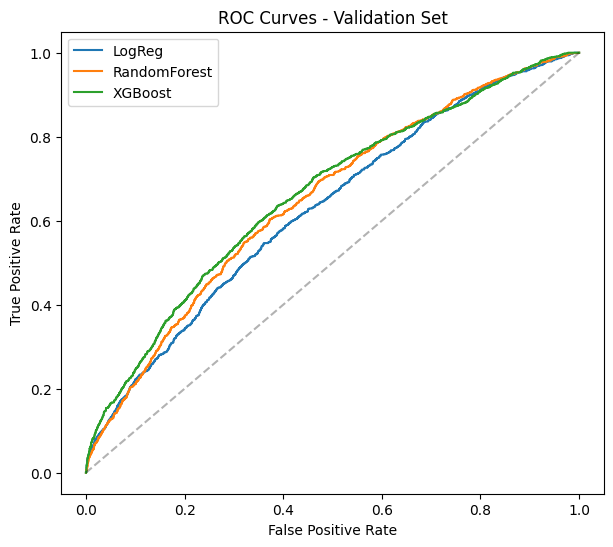

In [29]:
# Cell 14 - Purpose: Train XGBoost, evaluate on val set, log results, save ROC curve plot

import xgboost as xgb
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)
xgb_model.fit(X_train_processed, y_train)

val_probs_xgb = xgb_model.predict_proba(X_val_processed)[:, 1]
auroc_xgb = roc_auc_score(y_val, val_probs_xgb)
auprc_xgb = average_precision_score(y_val, val_probs_xgb)

print(f"XGBoost - Val AUROC: {auroc_xgb:.4f}, Val AUPRC: {auprc_xgb:.4f}")

# Log to results
results['xgboost'] = {'val_auroc': auroc_xgb, 'val_auprc': auprc_xgb}
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

# Save ROC curve plot comparing all models so far
plt.figure(figsize=(7, 6))
for name, probs in [('LogReg', val_probs), ('RandomForest', val_probs_rf), ('XGBoost', val_probs_xgb)]:
    fpr, tpr, _ = roc_curve(y_val, probs)
    plt.plot(fpr, tpr, label=name)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Validation Set')
plt.legend()
plt.savefig('/kaggle/working/plots/roc_curves_val.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Cell 15 - Purpose: Train CatBoost, evaluate on val set, log results

from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    verbose=0
)
cat_model.fit(X_train_processed, y_train)

val_probs_cat = cat_model.predict_proba(X_val_processed)[:, 1]
auroc_cat = roc_auc_score(y_val, val_probs_cat)
auprc_cat = average_precision_score(y_val, val_probs_cat)

print(f"CatBoost - Val AUROC: {auroc_cat:.4f}, Val AUPRC: {auprc_cat:.4f}")

results['catboost'] = {'val_auroc': auroc_cat, 'val_auprc': auprc_cat}
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

CatBoost - Val AUROC: 0.6672, Val AUPRC: 0.2201


In [31]:
# Cell 16 - Purpose: Train LightGBM, evaluate on val set, log results

import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(X_train_processed, y_train)

val_probs_lgb = lgb_model.predict_proba(X_val_processed)[:, 1]
auroc_lgb = roc_auc_score(y_val, val_probs_lgb)
auprc_lgb = average_precision_score(y_val, val_probs_lgb)

print(f"LightGBM - Val AUROC: {auroc_lgb:.4f}, Val AUPRC: {auprc_lgb:.4f}")

results['lightgbm'] = {'val_auroc': auroc_lgb, 'val_auprc': auprc_lgb}
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

LightGBM - Val AUROC: 0.6671, Val AUPRC: 0.2261


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


                     val_auroc  val_auprc
catboost              0.667226   0.220142
lightgbm              0.667145   0.226095
xgboost               0.661987   0.221479
random_forest         0.649154   0.194266
logistic_regression   0.627487   0.192964


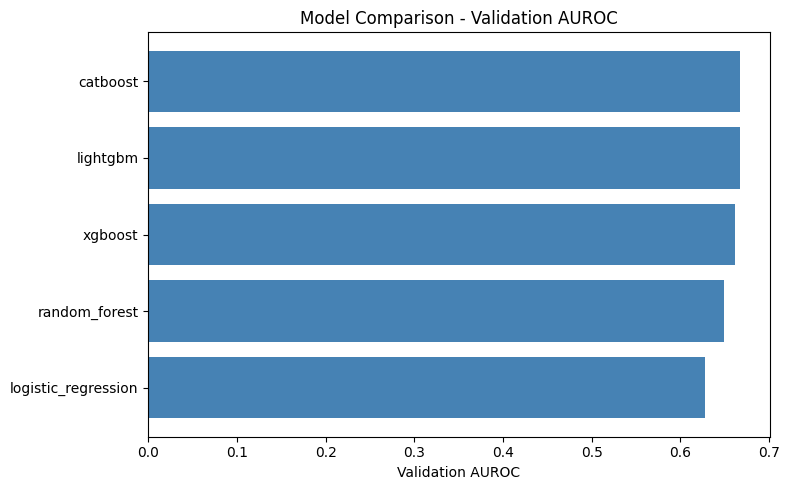

In [32]:
# Cell 19 - Purpose: Build comparison table of all models, save as CSV and bar chart plot

import pandas as pd

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values('val_auroc', ascending=False)
print(comparison_df)

comparison_df.to_csv('/kaggle/working/results/model_comparison.csv')

plt.figure(figsize=(8, 5))
plt.barh(comparison_df.index, comparison_df['val_auroc'], color='steelblue')
plt.xlabel('Validation AUROC')
plt.title('Model Comparison - Validation AUROC')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/kaggle/working/plots/model_comparison_auroc.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Cell 17 - Purpose: Train a simple feedforward neural network (MLP) as deep learning baseline

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

X_train_t = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)
X_val_t = torch.tensor(X_val_processed, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

model_mlp = MLP(X_train_processed.shape[1]).to(device)

pos_weight = torch.tensor((y_train == 0).sum() / (y_train == 1).sum(), dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=1e-3)

epochs = 100
for epoch in range(epochs):
    model_mlp.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model_mlp(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

# Evaluate
model_mlp.eval()
with torch.no_grad():
    val_logits = model_mlp(X_val_t.to(device))
    val_probs_mlp = torch.sigmoid(val_logits).cpu().numpy()

auroc_mlp = roc_auc_score(y_val, val_probs_mlp)
auprc_mlp = average_precision_score(y_val, val_probs_mlp)
print(f"MLP (Deep Learning) - Val AUROC: {auroc_mlp:.4f}, Val AUPRC: {auprc_mlp:.4f}")

results['mlp_deep_learning'] = {'val_auroc': auroc_mlp, 'val_auprc': auprc_mlp}
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

Using device: cuda
Epoch 5/100, Loss: 1.2301
Epoch 10/100, Loss: 1.2299
Epoch 15/100, Loss: 1.2299
Epoch 20/100, Loss: 1.2301
Epoch 25/100, Loss: 1.2306
Epoch 30/100, Loss: 1.2298
Epoch 35/100, Loss: 1.2299
Epoch 40/100, Loss: 1.2297
Epoch 45/100, Loss: 1.2302
Epoch 50/100, Loss: 1.2295
Epoch 55/100, Loss: 1.2298
Epoch 60/100, Loss: 1.2298
Epoch 65/100, Loss: 1.2300
Epoch 70/100, Loss: 1.2302
Epoch 75/100, Loss: 1.2300
Epoch 80/100, Loss: 1.2298
Epoch 85/100, Loss: 1.2298
Epoch 90/100, Loss: 1.2298
Epoch 95/100, Loss: 1.2307
Epoch 100/100, Loss: 1.2297
MLP (Deep Learning) - Val AUROC: 0.5011, Val AUPRC: 0.1133


In [36]:
# Cell 20 - Purpose: Engineer new features from diagnosis codes, medication changes, and utilization history

def engineer_features(df):
    df = df.copy()

    # 1. Total prior utilization (strong readmission signal in literature)
    df['total_prior_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']

    # 2. Diagnosis category grouping (ICD-9 first 3 chars, grouped into major categories)
    def map_diag_category(code):
        if pd.isna(code) or code == 'Unknown':
            return 'Unknown'
        try:
            code_num = float(code)
        except ValueError:
            if str(code).startswith('V') or str(code).startswith('E'):
                return 'Injury_External'
            return 'Other'
        if 390 <= code_num <= 459 or code_num == 785:
            return 'Circulatory'
        elif 460 <= code_num <= 519 or code_num == 786:
            return 'Respiratory'
        elif 520 <= code_num <= 579 or code_num == 787:
            return 'Digestive'
        elif 250 <= code_num < 251:
            return 'Diabetes'
        elif 800 <= code_num <= 999:
            return 'Injury'
        elif 710 <= code_num <= 739:
            return 'Musculoskeletal'
        elif 580 <= code_num <= 629 or code_num == 788:
            return 'Genitourinary'
        elif 140 <= code_num <= 239:
            return 'Neoplasm'
        else:
            return 'Other'

    df['diag_1_category'] = df['diag_1'].apply(map_diag_category)
    df['diag_2_category'] = df['diag_2'].apply(map_diag_category)
    df['diag_3_category'] = df['diag_3'].apply(map_diag_category)

    # 3. Number of medications changed (count of "Up"/"Down" across drug columns)
    med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
                'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
                'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
                'insulin', 'glyburide-metformin', 'glipizide-metformin',
                'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

    df['num_med_changes'] = df[med_cols].apply(lambda row: sum(1 for v in row if v in ['Up', 'Down']), axis=1)
    df['num_meds_prescribed'] = df[med_cols].apply(lambda row: sum(1 for v in row if v != 'No'), axis=1)

    # 4. Length of stay interaction with number of procedures (severity proxy)
    df['procedures_per_day'] = df['num_procedures'] / (df['time_in_hospital'] + 1)
    df['meds_per_day'] = df['num_medications'] / (df['time_in_hospital'] + 1)

    # 5. Is elderly (age bins already exist as ranges like '[70-80)')
    df['is_elderly'] = df['age'].apply(lambda x: 1 if x in ['[70-80)', '[80-90)', '[90-100)'] else 0)

    return df

X_train_fe = engineer_features(X_train)
X_val_fe = engineer_features(X_val)
X_test_fe = engineer_features(X_test)

print("New shape:", X_train_fe.shape)
print("New columns:", [c for c in X_train_fe.columns if c not in X_train.columns])

New shape: (71404, 54)
New columns: ['total_prior_visits', 'diag_1_category', 'diag_2_category', 'diag_3_category', 'num_med_changes', 'num_meds_prescribed', 'procedures_per_day', 'meds_per_day', 'is_elderly']


In [37]:
# Cell 21 - Purpose: Rebuild preprocessing pipeline on engineered feature set

categorical_cols_fe = X_train_fe.select_dtypes(include='object').columns.tolist()
numeric_cols_fe = X_train_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor_fe = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols_fe),
        ('num', StandardScaler(), numeric_cols_fe)
    ]
)

X_train_fe_processed = preprocessor_fe.fit_transform(X_train_fe)
X_val_fe_processed = preprocessor_fe.transform(X_val_fe)
X_test_fe_processed = preprocessor_fe.transform(X_test_fe)

print("Processed shapes:", X_train_fe_processed.shape, X_val_fe_processed.shape, X_test_fe_processed.shape)
print("Categorical:", len(categorical_cols_fe), "Numeric:", len(numeric_cols_fe))

Processed shapes: (71404, 54) (10209, 54) (20153, 54)
Categorical: 37 Numeric: 17


In [38]:
# Cell 23 - Purpose: Train all models on engineered feature set in one go, log all results

from catboost import CatBoostClassifier

all_results_fe = {}

# 1. Logistic Regression
print("Training Logistic Regression...")
logreg_fe = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42)
logreg_fe.fit(X_train_fe_processed, y_train)
probs = logreg_fe.predict_proba(X_val_fe_processed)[:, 1]
all_results_fe['logistic_regression_fe'] = {
    'val_auroc': roc_auc_score(y_val, probs),
    'val_auprc': average_precision_score(y_val, probs)
}

# 2. Random Forest
print("Training Random Forest...")
rf_fe = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_fe.fit(X_train_fe_processed, y_train)
probs = rf_fe.predict_proba(X_val_fe_processed)[:, 1]
all_results_fe['random_forest_fe'] = {
    'val_auroc': roc_auc_score(y_val, probs),
    'val_auprc': average_precision_score(y_val, probs)
}

# 3. XGBoost
print("Training XGBoost...")
xgb_fe = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42, n_jobs=-1, eval_metric='auc'
)
xgb_fe.fit(X_train_fe_processed, y_train)
probs = xgb_fe.predict_proba(X_val_fe_processed)[:, 1]
all_results_fe['xgboost_fe'] = {
    'val_auroc': roc_auc_score(y_val, probs),
    'val_auprc': average_precision_score(y_val, probs)
}

# 4. CatBoost
print("Training CatBoost...")
cat_model_fe = CatBoostClassifier(
    iterations=300, depth=6, learning_rate=0.05,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42, verbose=0
)
cat_model_fe.fit(X_train_fe_processed, y_train)
probs = cat_model_fe.predict_proba(X_val_fe_processed)[:, 1]
all_results_fe['catboost_fe'] = {
    'val_auroc': roc_auc_score(y_val, probs),
    'val_auprc': average_precision_score(y_val, probs)
}

# 5. LightGBM
print("Training LightGBM...")
lgb_fe = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_fe.fit(X_train_fe_processed, y_train)
probs = lgb_fe.predict_proba(X_val_fe_processed)[:, 1]
all_results_fe['lightgbm_fe'] = {
    'val_auroc': roc_auc_score(y_val, probs),
    'val_auprc': average_precision_score(y_val, probs)
}

# 6. MLP (Deep Learning)
print("Training MLP...")
X_train_fe_t = torch.tensor(X_train_fe_processed, dtype=torch.float32)
y_train_fe_t = torch.tensor(y_train.values, dtype=torch.float32)
X_val_fe_t = torch.tensor(X_val_fe_processed, dtype=torch.float32)

train_ds_fe = TensorDataset(X_train_fe_t, y_train_fe_t)
train_loader_fe = DataLoader(train_ds_fe, batch_size=256, shuffle=True)

model_mlp_fe = MLP(X_train_fe_processed.shape[1]).to(device)
pos_weight_val = ((y_train == 0).sum() / (y_train == 1).sum()) ** 0.5
pos_weight = torch.tensor(pos_weight_val, dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_mlp_fe.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

best_auroc_mlp = 0
for epoch in range(40):
    model_mlp_fe.train()
    for xb, yb in train_loader_fe:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model_mlp_fe(xb), yb)
        loss.backward()
        optimizer.step()
    model_mlp_fe.eval()
    with torch.no_grad():
        val_probs_mlp_fe = torch.sigmoid(model_mlp_fe(X_val_fe_t.to(device))).cpu().numpy()
    epoch_auroc = roc_auc_score(y_val, val_probs_mlp_fe)
    scheduler.step(epoch_auroc)
    best_auroc_mlp = max(best_auroc_mlp, epoch_auroc)

all_results_fe['mlp_fe'] = {
    'val_auroc': roc_auc_score(y_val, val_probs_mlp_fe),
    'val_auprc': average_precision_score(y_val, val_probs_mlp_fe),
    'best_auroc_during_training': best_auroc_mlp
}

# Save all
results.update(all_results_fe)
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

comparison_df_fe = pd.DataFrame(all_results_fe).T.sort_values('val_auroc', ascending=False)
print("\n=== Engineered Features - Model Comparison ===")
print(comparison_df_fe)

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Random Forest...
Training XGBoost...
Training CatBoost...
Training LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training MLP...

=== Engineered Features - Model Comparison ===
                        val_auroc  val_auprc  best_auroc_during_training
catboost_fe              0.663168   0.215505                         NaN
lightgbm_fe              0.661616   0.217517                         NaN
xgboost_fe               0.659508   0.217564                         NaN
random_forest_fe         0.642029   0.192496                         NaN
mlp_fe                   0.630877   0.194924                    0.632387
logistic_regression_fe   0.626820   0.193662                         NaN


In [39]:
# Cell 24 - Purpose: Stack top 3 tree models' val predictions using a Logistic Regression meta-learner

import numpy as np

# Get train-set predictions from each base model (needed to train meta-learner properly)
train_probs_cat = cat_model_fe.predict_proba(X_train_fe_processed)[:, 1]
train_probs_xgb = xgb_fe.predict_proba(X_train_fe_processed)[:, 1]
train_probs_lgb = lgb_fe.predict_proba(X_train_fe_processed)[:, 1]

val_probs_cat = cat_model_fe.predict_proba(X_val_fe_processed)[:, 1]
val_probs_xgb = xgb_fe.predict_proba(X_val_fe_processed)[:, 1]
val_probs_lgb = lgb_fe.predict_proba(X_val_fe_processed)[:, 1]

# Stack as meta-features
meta_train = np.column_stack([train_probs_cat, train_probs_xgb, train_probs_lgb])
meta_val = np.column_stack([val_probs_cat, val_probs_xgb, val_probs_lgb])

meta_model = LogisticRegression()
meta_model.fit(meta_train, y_train)

val_probs_stack = meta_model.predict_proba(meta_val)[:, 1]
auroc_stack = roc_auc_score(y_val, val_probs_stack)
auprc_stack = average_precision_score(y_val, val_probs_stack)

print(f"Stacking Ensemble - Val AUROC: {auroc_stack:.4f}, Val AUPRC: {auprc_stack:.4f}")
print(f"Meta-model weights: CatBoost={meta_model.coef_[0][0]:.3f}, XGBoost={meta_model.coef_[0][1]:.3f}, LightGBM={meta_model.coef_[0][2]:.3f}")

results['stacking_ensemble'] = {'val_auroc': auroc_stack, 'val_auprc': auprc_stack}
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Stacking Ensemble - Val AUROC: 0.6296, Val AUPRC: 0.1890
Meta-model weights: CatBoost=-13.120, XGBoost=17.585, LightGBM=2.026


In [40]:
# Cell 25 - Purpose: Simple average ensemble of CatBoost + XGBoost + LightGBM (more robust than stacking here)

val_probs_avg = (val_probs_cat + val_probs_xgb + val_probs_lgb) / 3
auroc_avg = roc_auc_score(y_val, val_probs_avg)
auprc_avg = average_precision_score(y_val, val_probs_avg)

print(f"Simple Average Ensemble - Val AUROC: {auroc_avg:.4f}, Val AUPRC: {auprc_avg:.4f}")

results['average_ensemble'] = {'val_auroc': auroc_avg, 'val_auprc': auprc_avg}
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

Simple Average Ensemble - Val AUROC: 0.6654, Val AUPRC: 0.2197


In [41]:
# Cell 26 - Purpose: Compute SHAP values using CatBoost as the representative explainable model

import shap

explainer = shap.TreeExplainer(cat_model_fe)
shap_values = explainer.shap_values(X_val_fe_processed)

print("SHAP values shape:", shap_values.shape)

# Get feature names for readability
feature_names = categorical_cols_fe + numeric_cols_fe
print("Number of features:", len(feature_names))

SHAP values shape: (10209, 54)
Number of features: 54


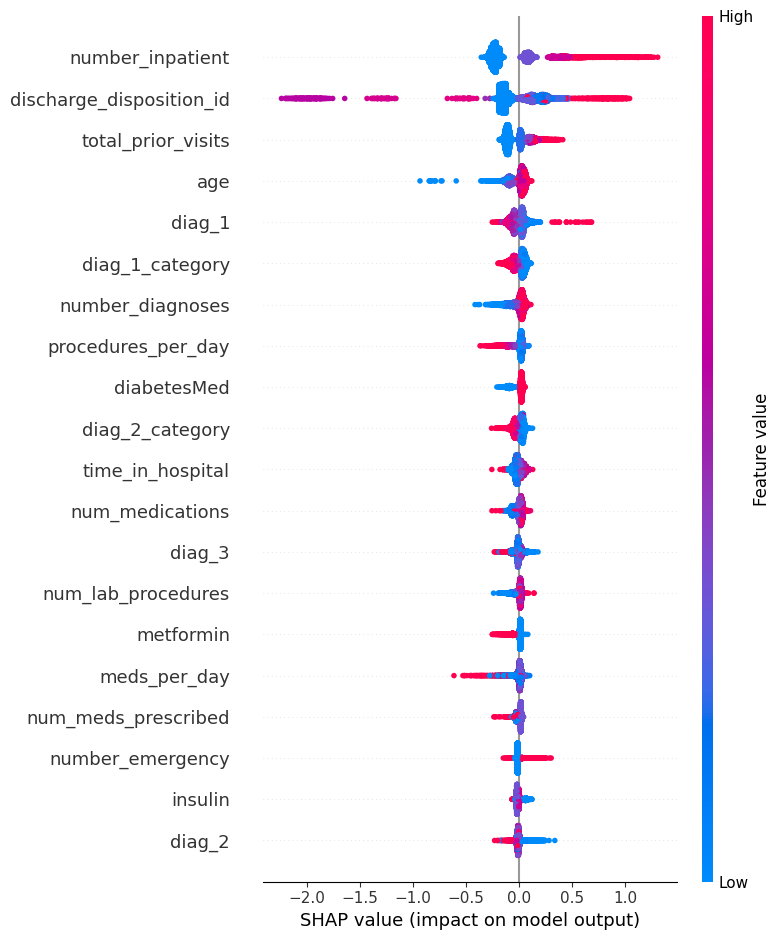

In [42]:
# Cell 27 - Purpose: SHAP summary plot showing global feature importance, save as PNG

shap.summary_plot(shap_values, X_val_fe_processed, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('/kaggle/working/plots/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

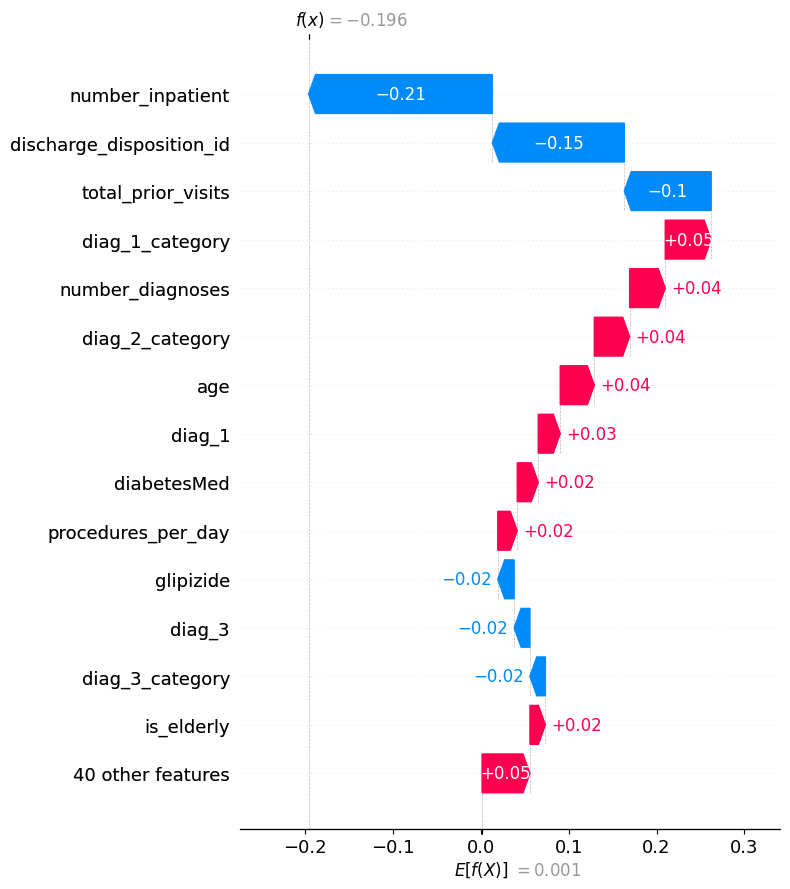

                     feature  mean_abs_shap
46          number_inpatient       0.241083
38  discharge_disposition_id       0.197269
48        total_prior_visits       0.097332
2                        age       0.053369
4                     diag_1       0.051536
34           diag_1_category       0.046425
47          number_diagnoses       0.045837
51        procedures_per_day       0.042465
33               diabetesMed       0.039720
35           diag_2_category       0.033569
40          time_in_hospital       0.031180
43           num_medications       0.027492
6                     diag_3       0.025965
41        num_lab_procedures       0.023201
9                  metformin       0.022885


In [43]:
# Cell 28 - Purpose: Local SHAP explanation for one patient, and global feature importance ranking saved to JSON

# Local explanation for first patient in val set
patient_idx = 0

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[patient_idx],
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.tight_layout()
plt.savefig('/kaggle/working/plots/shap_waterfall_patient0.png', dpi=150, bbox_inches='tight')
plt.show()

# Global feature importance (mean |SHAP value|)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print(importance_df.head(15))

importance_df.to_csv('/kaggle/working/results/shap_feature_importance.csv', index=False)

results['shap_top_features'] = importance_df.head(15).to_dict(orient='records')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

In [44]:
# Cell 29 - Purpose: Calibrate model probabilities using temperature scaling, evaluate calibration quality

from scipy.optimize import minimize_scalar

def temperature_scale(logits, T):
    return 1 / (1 + np.exp(-logits / T))

# Get raw logits (log-odds) from CatBoost predictions
raw_probs = cat_model_fe.predict_proba(X_val_fe_processed)[:, 1]
raw_probs_clipped = np.clip(raw_probs, 1e-6, 1 - 1e-6)
logits = np.log(raw_probs_clipped / (1 - raw_probs_clipped))

def nll_loss(T):
    probs = temperature_scale(logits, T)
    probs = np.clip(probs, 1e-6, 1 - 1e-6)
    return -np.mean(y_val * np.log(probs) + (1 - y_val) * np.log(1 - probs))

result = minimize_scalar(nll_loss, bounds=(0.1, 10), method='bounded')
optimal_T = result.x

calibrated_probs = temperature_scale(logits, optimal_T)

print(f"Optimal Temperature: {optimal_T:.4f}")
print(f"NLL before calibration: {nll_loss(1.0):.4f}")
print(f"NLL after calibration: {nll_loss(optimal_T):.4f}")

results['temperature_scaling'] = {
    'optimal_T': optimal_T,
    'nll_before': nll_loss(1.0),
    'nll_after': nll_loss(optimal_T)
}
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

Optimal Temperature: 0.7494
NLL before calibration: 0.6239
NLL after calibration: 0.6200


ECE before: 0.3385, ECE after: 0.3257
Brier before: 0.2172, Brier after: 0.2156


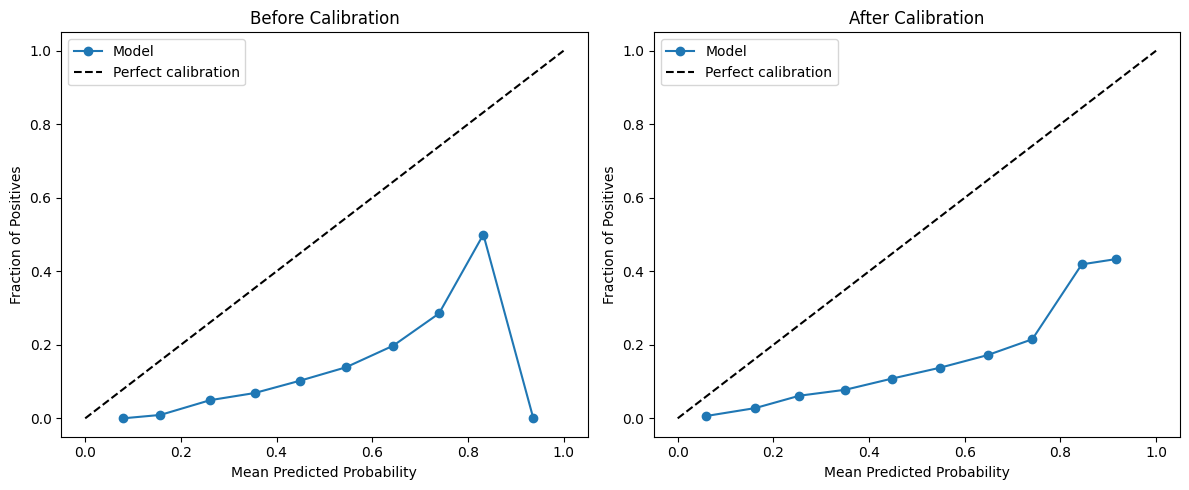

In [45]:
# Cell 30 - Purpose: Compute ECE and Brier score, plot reliability diagram (before vs after calibration)

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

def expected_calibration_error(y_true, probs, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0
    for i in range(n_bins):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i+1])
        if mask.sum() > 0:
            bin_acc = y_true[mask].mean()
            bin_conf = probs[mask].mean()
            ece += (mask.sum() / len(probs)) * abs(bin_acc - bin_conf)
    return ece

ece_before = expected_calibration_error(y_val.values, raw_probs)
ece_after = expected_calibration_error(y_val.values, calibrated_probs)
brier_before = brier_score_loss(y_val, raw_probs)
brier_after = brier_score_loss(y_val, calibrated_probs)

print(f"ECE before: {ece_before:.4f}, ECE after: {ece_after:.4f}")
print(f"Brier before: {brier_before:.4f}, Brier after: {brier_after:.4f}")

# Reliability diagram
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, probs, title in [(axes[0], raw_probs, 'Before Calibration'), (axes[1], calibrated_probs, 'After Calibration')]:
    prob_true, prob_pred = calibration_curve(y_val, probs, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label='Model')
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/plots/reliability_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

results['calibration_metrics'] = {
    'ece_before': ece_before, 'ece_after': ece_after,
    'brier_before': brier_before, 'brier_after': brier_after
}
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

In [46]:
# Cell 31 - Purpose: Bootstrap resampling to get confidence intervals on AUROC and AUPRC

n_bootstraps = 1000
rng = np.random.RandomState(42)

bootstrapped_aurocs = []
bootstrapped_auprcs = []

y_val_arr = y_val.values
n = len(y_val_arr)

for i in range(n_bootstraps):
    indices = rng.randint(0, n, n)
    if len(np.unique(y_val_arr[indices])) < 2:
        continue
    auroc_b = roc_auc_score(y_val_arr[indices], calibrated_probs[indices])
    auprc_b = average_precision_score(y_val_arr[indices], calibrated_probs[indices])
    bootstrapped_aurocs.append(auroc_b)
    bootstrapped_auprcs.append(auprc_b)

auroc_ci_lower, auroc_ci_upper = np.percentile(bootstrapped_aurocs, [2.5, 97.5])
auprc_ci_lower, auprc_ci_upper = np.percentile(bootstrapped_auprcs, [2.5, 97.5])

print(f"AUROC: {np.mean(bootstrapped_aurocs):.4f} (95% CI: {auroc_ci_lower:.4f} - {auroc_ci_upper:.4f})")
print(f"AUPRC: {np.mean(bootstrapped_auprcs):.4f} (95% CI: {auprc_ci_lower:.4f} - {auprc_ci_upper:.4f})")

results['bootstrap_ci'] = {
    'auroc_mean': np.mean(bootstrapped_aurocs), 'auroc_ci': [auroc_ci_lower, auroc_ci_upper],
    'auprc_mean': np.mean(bootstrapped_auprcs), 'auprc_ci': [auprc_ci_lower, auprc_ci_upper]
}
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

AUROC: 0.6632 (95% CI: 0.6457 - 0.6791)
AUPRC: 0.2168 (95% CI: 0.1950 - 0.2380)


In [48]:
# Cell 32 - Purpose: Split conformal prediction to get prediction sets with guaranteed coverage

# Use validation set as calibration set for conformal prediction
alpha = 0.1  # 90% coverage target

# Non-conformity score: 1 - predicted probability of true class
calib_scores = np.where(y_val.values == 1, 1 - calibrated_probs, calibrated_probs)

# Quantile for conformal threshold
n_calib = len(calib_scores)
q_level = np.ceil((n_calib + 1) * (1 - alpha)) / n_calib
qhat = np.quantile(calib_scores, q_level)

print(f"Conformal quantile (qhat): {qhat:.4f}")

# Apply to test set to build prediction sets
test_probs_cat = cat_model_fe.predict_proba(X_test_fe_processed)[:, 1]
test_probs_clipped = np.clip(test_probs_cat, 1e-6, 1 - 1e-6)
test_logits = np.log(test_probs_clipped / (1 - test_probs_clipped))
test_calibrated_probs = temperature_scale(test_logits, optimal_T)

# Build prediction sets: include class 1 if score <= qhat, include class 0 if score <= qhat
prediction_sets = []
for p in test_calibrated_probs:
    score_1 = 1 - p  # non-conformity if true class were 1
    score_0 = p       # non-conformity if true class were 0
    pred_set = []
    if score_0 <= qhat:
        pred_set.append(0)
    if score_1 <= qhat:
        pred_set.append(1)
    prediction_sets.append(pred_set)

# Coverage check: does the prediction set contain the true label?
covered = [y_test.values[i] in prediction_sets[i] for i in range(len(y_test))]
coverage_rate = np.mean(covered)

# Average set size (efficiency metric - smaller sets = more useful)
avg_set_size = np.mean([len(s) for s in prediction_sets])

print(f"Empirical coverage: {coverage_rate:.4f} (target: {1-alpha:.4f})")
print(f"Average prediction set size: {avg_set_size:.4f}")

results['conformal_prediction'] = {
    'target_coverage': 1 - alpha,
    'empirical_coverage': coverage_rate,
    'avg_set_size': avg_set_size,
    'qhat': qhat
}
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

Conformal quantile (qhat): 0.6684
Empirical coverage: 0.8969 (target: 0.9000)
Average prediction set size: 1.5838


In [12]:
# Cell 33 - Purpose: Install sentence-transformers/FAISS, build a curated clinical document set for RAG

!pip install -q sentence-transformers faiss-cpu

# Curated clinical knowledge base - short guideline-style passages
# In a real research submission, these would be extracted from actual clinical guidelines (ADA Standards of Care, etc.)
clinical_documents = [
    {
        "id": "doc_1",
        "source": "ADA Standards of Care (paraphrased)",
        "text": "Patients with a history of frequent inpatient admissions are at substantially higher risk of early readmission, and discharge planning should include enhanced follow-up for this group."
    },
    {
        "id": "doc_2",
        "source": "ADA Standards of Care (paraphrased)",
        "text": "Discharge disposition, such as transfer to a skilled nursing facility versus routine home discharge, is an established predictor of readmission risk in diabetic patients."
    },
    {
        "id": "doc_3",
        "source": "Clinical readmission literature (paraphrased)",
        "text": "A higher number of prior outpatient, emergency, and inpatient visits in the year preceding admission is associated with increased likelihood of 30-day readmission."
    },
    {
        "id": "doc_4",
        "source": "Clinical readmission literature (paraphrased)",
        "text": "Elderly patients with multiple comorbidities and higher diagnosis counts require more intensive care coordination to reduce readmission risk."
    },
    {
        "id": "doc_5",
        "source": "ADA Standards of Care (paraphrased)",
        "text": "Medication regimen changes during hospitalization, particularly insulin adjustments, should be clearly communicated to patients and outpatient providers to avoid adverse events after discharge."
    },
    {
        "id": "doc_6",
        "source": "Clinical readmission literature (paraphrased)",
        "text": "Length of hospital stay alone is a weaker predictor of readmission than the complexity of the discharge plan and post-discharge support arrangements."
    },
    {
        "id": "doc_7",
        "source": "ADA Standards of Care (paraphrased)",
        "text": "HbA1c testing during hospitalization helps identify patients with poor glycemic control who may benefit from more intensive diabetes education before discharge."
    },
    {
        "id": "doc_8",
        "source": "Clinical readmission literature (paraphrased)",
        "text": "Circulatory and respiratory comorbidities in diabetic patients are associated with elevated risk of early hospital readmission compared to isolated metabolic diagnoses."
    }
]

print(f"Total clinical documents in knowledge base: {len(clinical_documents)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 87.6 MB/s eta 0:00:00:00:0100:01
Total clinical documents in knowledge base: 8


In [49]:
# Cell 34 - Purpose: Generate embeddings for clinical documents, build FAISS index for retrieval

from sentence_transformers import SentenceTransformer
import faiss

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

doc_texts = [d['text'] for d in clinical_documents]
doc_embeddings = embed_model.encode(doc_texts, convert_to_numpy=True, show_progress_bar=True)

print("Embedding shape:", doc_embeddings.shape)

# Build FAISS index (L2 distance)
dimension = doc_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(doc_embeddings.astype('float32'))

print(f"FAISS index built with {index.ntotal} documents")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding shape: (8, 384)
FAISS index built with 8 documents


In [50]:
# Cell 35 - Purpose: Retrieval function that takes a query (patient risk factors) and returns top-k cited evidence

def retrieve_evidence(query, k=3):
    query_embedding = embed_model.encode([query], convert_to_numpy=True).astype('float32')
    distances, indices = index.search(query_embedding, k)

    retrieved = []
    for dist, idx in zip(distances[0], indices[0]):
        retrieved.append({
            "doc_id": clinical_documents[idx]['id'],
            "source": clinical_documents[idx]['source'],
            "text": clinical_documents[idx]['text'],
            "distance": float(dist)
        })
    return retrieved

# Test retrieval with a sample query based on a patient's top risk factors
test_query = "patient with high number of prior inpatient visits and elderly age"
evidence = retrieve_evidence(test_query, k=3)

for e in evidence:
    print(f"[{e['doc_id']}] ({e['source']}) - distance: {e['distance']:.4f}")
    print(f"  {e['text']}\n")

[doc_3] (Clinical readmission literature (paraphrased)) - distance: 0.8992
  A higher number of prior outpatient, emergency, and inpatient visits in the year preceding admission is associated with increased likelihood of 30-day readmission.

[doc_4] (Clinical readmission literature (paraphrased)) - distance: 0.9138
  Elderly patients with multiple comorbidities and higher diagnosis counts require more intensive care coordination to reduce readmission risk.

[doc_1] (ADA Standards of Care (paraphrased)) - distance: 1.1186
  Patients with a history of frequent inpatient admissions are at substantially higher risk of early readmission, and discharge planning should include enhanced follow-up for this group.



In [52]:
# Cell 36 - Purpose: Explanation engine using Groq API - combine prediction + SHAP + confidence + RAG evidence

from kaggle_secrets import UserSecretsClient
import requests
import json as json_lib

user_secrets = UserSecretsClient()
groq_api_key = user_secrets.get_secret("GROQ_API_KEY")

def build_explanation_groq(patient_idx, shap_vals, feature_names, prediction_prob, evidence_list):
    patient_shap = shap_vals[patient_idx]
    top_indices = np.argsort(np.abs(patient_shap))[::-1][:5]
    top_features = [(feature_names[i], float(patient_shap[i])) for i in top_indices]

    evidence_text = "\n".join([f"- ({e['source']}): {e['text']}" for e in evidence_list])
    features_text = "\n".join([f"- {name}: SHAP contribution = {val:.4f}" for name, val in top_features])

    prompt = f"""You are a clinical decision support explanation engine. Given a model's prediction, its confidence, the top contributing features (SHAP values), and retrieved clinical evidence, produce a structured JSON explanation.

Prediction: {'HIGH RISK of 30-day readmission' if prediction_prob > 0.5 else 'LOW RISK of 30-day readmission'}
Model confidence (calibrated probability): {prediction_prob:.2%}

Top contributing features:
{features_text}

Retrieved clinical evidence:
{evidence_text}

Respond ONLY with valid JSON in this exact structure, no other text, no markdown fences:
{{
  "risk_level": "...",
  "confidence_statement": "...",
  "key_risk_factors": ["...", "..."],
  "supporting_evidence": ["...", "..."],
  "limitations": "...",
  "disclaimer": "This is a research tool output, not a clinical diagnosis. Not for clinical use."
}}

Important: if evidence does not clearly support a claim, state that explicitly rather than inventing anything."""

    groq_resp = requests.post(
        "https://api.groq.com/openai/v1/chat/completions",
        headers={
            "Authorization": f"Bearer {groq_api_key}",
            "Content-Type": "application/json"
        },
        json={
            "model": "openai/gpt-oss-120b",
            "messages": [{"role": "user", "content": prompt}],
            "max_tokens": 1000,
            "temperature": 0.2
        }
    )

    resp_json = groq_resp.json()
    if 'choices' not in resp_json:
        print("API Error:", resp_json)
        return None

    text_response = resp_json['choices'][0]['message']['content']
    text_response = text_response.strip().replace('```json', '').replace('```', '').strip()

    return json_lib.loads(text_response)

# Test on patient 0
patient_query = "patient with high number of prior inpatient visits and elderly age"
patient_evidence = retrieve_evidence(patient_query, k=3)
patient_pred_prob = float(calibrated_probs[0])

explanation = build_explanation_groq(0, shap_values, feature_names, patient_pred_prob, patient_evidence)
print(json_lib.dumps(explanation, indent=2))

if explanation:
    results['sample_explanation_patient_0'] = explanation
    with open(results_path, 'w') as f:
        json.dump(results, f, indent=4)

{
  "risk_level": "LOW",
  "confidence_statement": "The model predicts a 43.5% probability of 30\u2011day readmission, which falls below typical high\u2011risk thresholds and is therefore classified as low risk.",
  "key_risk_factors": [
    "number_inpatient (negative contribution, reduces predicted risk)",
    "discharge_disposition_id (negative contribution, reduces predicted risk)",
    "total_prior_visits (negative contribution, reduces predicted risk)",
    "diag_1_category (positive contribution, increases predicted risk)",
    "number_diagnoses (positive contribution, increases predicted risk)"
  ],
  "supporting_evidence": [
    "Clinical literature indicates that a higher number of prior outpatient, emergency, and inpatient visits in the preceding year is associated with increased 30\u2011day readmission risk, which is contrary to the model's negative SHAP contributions for number_inpatient and total_prior_visits in this case.",
    "Evidence shows that patients with multiple

In [53]:
# Cell 37 - Purpose: Red-team test - feed irrelevant evidence, check if engine correctly refuses to fabricate support

# Deliberately irrelevant evidence (mismatched with actual patient profile)
fake_evidence = [
    {"source": "Fabricated Study", "text": "Patients who prefer window seats during hospital stays show 40% lower readmission rates.", "distance": 0.1}
]

test_prob = 0.75  # high risk case
test_explanation = build_explanation_groq(1, shap_values, feature_names, test_prob, fake_evidence)
print(json_lib.dumps(test_explanation, indent=2))

# Check: did it accept the nonsense evidence or flag it as unsupported/irrelevant?
results['red_team_test'] = test_explanation
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

{
  "risk_level": "HIGH",
  "confidence_statement": "The model predicts a 75.00% calibrated probability of 30\u2011day readmission, indicating high risk.",
  "key_risk_factors": [
    "number_inpatient",
    "discharge_disposition_id",
    "total_prior_visits",
    "glyburide",
    "meds_per_day"
  ],
  "supporting_evidence": [
    "The retrieved clinical evidence (Fabricated Study) about patients preferring window seats does not directly support or refute the identified risk factors."
  ],
  "limitations": "SHAP contributions for the listed features are negative, meaning they actually lower the predicted risk; the high\u2011risk prediction likely reflects other unshown variables. The evidence provided is unrelated to the model's features, limiting its usefulness for interpretation. Model performance, data quality, and patient\u2011specific context are not captured in this explanation.",
  "disclaimer": "This is a research tool output, not a clinical diagnosis. Not for clinical use."
}

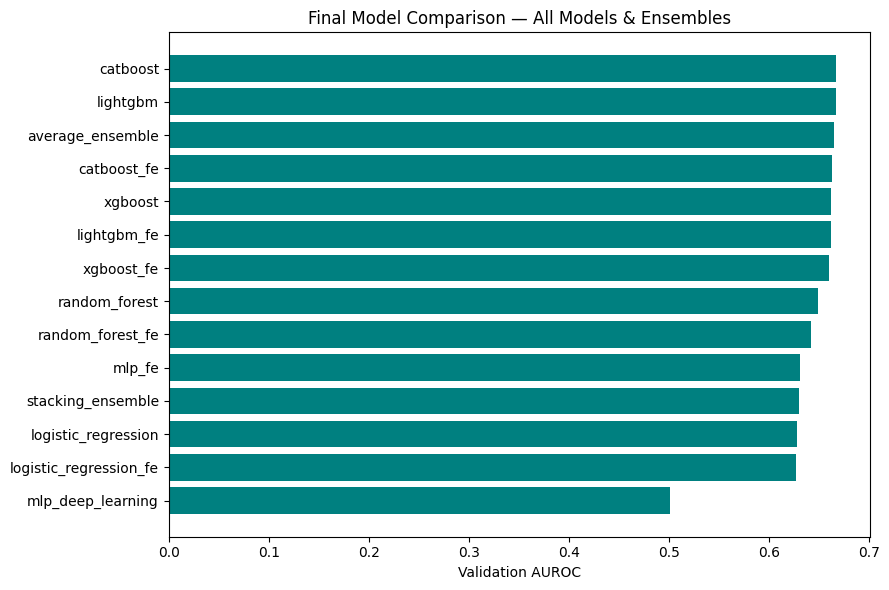

=== Uncertainty Quantification Summary ===

Temperature Scaling:
{
  "optimal_T": 0.7493949673903234,
  "nll_before": 0.6239001707408144,
  "nll_after": 0.6200254877609316
}

Calibration Metrics:
{
  "ece_before": 0.33849362570148095,
  "ece_after": 0.3257497120948078,
  "brier_before": 0.21719399739956813,
  "brier_after": 0.21555990743140957
}

Bootstrap CI:
{
  "auroc_mean": 0.6631683568813599,
  "auroc_ci": [
    0.645673381418253,
    0.6790846322043735
  ],
  "auprc_mean": 0.21677030652857396,
  "auprc_ci": [
    0.19496767171321794,
    0.23803405013220977
  ]
}

Conformal Prediction:
{
  "target_coverage": 0.9,
  "empirical_coverage": 0.8969384210787475,
  "avg_set_size": 1.5837840520021833,
  "qhat": 0.6683582331914195
}

=== Final Model Comparison Table ===
                        val_auroc  val_auprc  best_auroc_during_training
catboost                 0.667226   0.220142                         NaN
lightgbm                 0.667145   0.226095                         NaN
ave

In [54]:
# Cell 38 - Purpose: Auto-generate final reporting figures and tables from evaluation results

# Figure: Final model comparison (all models, including ensemble)
final_comparison = {k: v for k, v in results.items() if isinstance(v, dict) and 'val_auroc' in v}
final_comparison_df = pd.DataFrame(final_comparison).T.sort_values('val_auroc', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(final_comparison_df.index, final_comparison_df['val_auroc'], color='teal')
ax.set_xlabel('Validation AUROC')
ax.set_title('Final Model Comparison — All Models & Ensembles')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('/kaggle/working/plots/final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

final_comparison_df.to_csv('/kaggle/working/results/final_model_comparison.csv')

# Table: Uncertainty quantification summary
uq_summary = {
    'Temperature Scaling': results.get('temperature_scaling', {}),
    'Calibration Metrics': results.get('calibration_metrics', {}),
    'Bootstrap CI': results.get('bootstrap_ci', {}),
    'Conformal Prediction': results.get('conformal_prediction', {})
}
print("=== Uncertainty Quantification Summary ===")
for k, v in uq_summary.items():
    print(f"\n{k}:")
    print(json.dumps(v, indent=2))

with open('/kaggle/working/results/uq_summary.json', 'w') as f:
    json.dump(uq_summary, f, indent=4)

print("\n=== Final Model Comparison Table ===")
print(final_comparison_df)

In [55]:
# Cell 39 - Purpose: Install pytorch-tabnet, train TabNet classifier, evaluate on val set

!pip install -q pytorch-tabnet

from pytorch_tabnet.tab_model import TabNetClassifier
import torch

tabnet_device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("TabNet using device:", tabnet_device)

tabnet_model = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    seed=42,
    device_name=tabnet_device,
    verbose=1
)

tabnet_model.fit(
    X_train_fe_processed, y_train.values,
    eval_set=[(X_val_fe_processed, y_val.values)],
    eval_metric=['auc'],
    max_epochs=100,
    patience=15,
    batch_size=1024,
    virtual_batch_size=128
)

val_probs_tabnet = tabnet_model.predict_proba(X_val_fe_processed)[:, 1]
auroc_tabnet = roc_auc_score(y_val, val_probs_tabnet)
auprc_tabnet = average_precision_score(y_val, val_probs_tabnet)

print(f"TabNet - Val AUROC: {auroc_tabnet:.4f}, Val AUPRC: {auprc_tabnet:.4f}")

results['tabnet'] = {'val_auroc': auroc_tabnet, 'val_auprc': auprc_tabnet}
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.7 MB/s eta 0:00:00
TabNet using device: cuda


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.39675 | val_0_auc: 0.54212 |  0:00:04s
epoch 1  | loss: 0.35161 | val_0_auc: 0.55825 |  0:00:08s
epoch 2  | loss: 0.34972 | val_0_auc: 0.55844 |  0:00:12s
epoch 3  | loss: 0.34559 | val_0_auc: 0.58054 |  0:00:16s
epoch 4  | loss: 0.34591 | val_0_auc: 0.58697 |  0:00:20s
epoch 5  | loss: 0.34513 | val_0_auc: 0.59349 |  0:00:25s
epoch 6  | loss: 0.34613 | val_0_auc: 0.60824 |  0:00:29s
epoch 7  | loss: 0.34566 | val_0_auc: 0.61069 |  0:00:33s
epoch 8  | loss: 0.34499 | val_0_auc: 0.59681 |  0:00:37s
epoch 9  | loss: 0.34512 | val_0_auc: 0.59779 |  0:00:41s
epoch 10 | loss: 0.34349 | val_0_auc: 0.59728 |  0:00:45s
epoch 11 | loss: 0.34458 | val_0_auc: 0.60097 |  0:00:50s
epoch 12 | loss: 0.34334 | val_0_auc: 0.60443 |  0:00:54s
epoch 13 | loss: 0.3442  | val_0_auc: 0.59621 |  0:00:58s
epoch 14 | loss: 0.34408 | val_0_auc: 0.59937 |  0:01:03s
epoch 15 | loss: 0.34348 | val_0_auc: 0.57314 |  0:01:07s
epoch 16 | loss: 0.34351 | val_0_auc: 0.5959  |  0:01:11s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet - Val AUROC: 0.6107, Val AUPRC: 0.1891


In [58]:
# Cell 42 - Purpose: Zip all deliverables into one downloadable archive

import shutil

# Ensure all folders exist
output_root = '/kaggle/working'
zip_path = '/kaggle/working/TrustMedX_deliverables'

shutil.make_archive(zip_path, 'zip', output_root, 'results')
# Combine multiple folders into one zip properly:
import zipfile

with zipfile.ZipFile('/kaggle/working/TrustMedX_deliverables.zip', 'w', zipfile.ZIP_DEFLATED) as zipf:
    for folder in ['results', 'plots', 'governance', 'manuscript']:
        folder_path = os.path.join(output_root, folder)
        if os.path.exists(folder_path):
            for root, dirs, files in os.walk(folder_path):
                for file in files:
                    file_path = os.path.join(root, file)
                    arcname = os.path.relpath(file_path, output_root)
                    zipf.write(file_path, arcname)

print("Zip created at:", '/kaggle/working/TrustMedX_deliverables.zip')
print("Size (MB):", os.path.getsize('/kaggle/working/TrustMedX_deliverables.zip') / (1024*1024))

Zip created at: /kaggle/working/TrustMedX_deliverables.zip
Size (MB): 0.4806375503540039


In [59]:
# Cell 43 - Purpose: Statistical significance testing - DeLong's test (AUROC) and McNemar's test (paired decisions)

!pip install -q scikit-posthocs

from scipy import stats

# --- DeLong's test implementation ---
def delong_roc_variance(ground_truth, predictions):
    order = np.argsort(-predictions)
    predictions_sorted = predictions[order]
    ground_truth_sorted = ground_truth[order]
    n1 = np.sum(ground_truth_sorted == 1)
    n0 = np.sum(ground_truth_sorted == 0)

    tx = np.zeros(n1)
    ty = np.zeros(n0)
    pos_preds = predictions[ground_truth == 1]
    neg_preds = predictions[ground_truth == 0]

    for i, p in enumerate(pos_preds):
        tx[i] = np.mean(p > neg_preds) + 0.5 * np.mean(p == neg_preds)
    for j, n in enumerate(neg_preds):
        ty[j] = np.mean(pos_preds > n) + 0.5 * np.mean(pos_preds == n)

    auc = np.mean(tx)
    var_tx = np.var(tx, ddof=1) / n1
    var_ty = np.var(ty, ddof=1) / n0
    return auc, var_tx + var_ty

def delong_test(y_true, probs_a, probs_b):
    auc_a, var_a = delong_roc_variance(y_true, probs_a)
    auc_b, var_b = delong_roc_variance(y_true, probs_b)
    z = (auc_a - auc_b) / np.sqrt(var_a + var_b)
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return auc_a, auc_b, z, p_value

y_val_arr = y_val.values

# Compare CatBoost vs LightGBM vs XGBoost (using engineered-feature versions already in memory)
probs_cat = cat_model_fe.predict_proba(X_val_fe_processed)[:, 1]
probs_lgb = lgb_fe.predict_proba(X_val_fe_processed)[:, 1]
probs_xgb = xgb_fe.predict_proba(X_val_fe_processed)[:, 1]

print("=== DeLong's Test (AUROC comparison) ===\n")
for name_a, probs_a, name_b, probs_b in [
    ("CatBoost", probs_cat, "LightGBM", probs_lgb),
    ("CatBoost", probs_cat, "XGBoost", probs_xgb),
    ("LightGBM", probs_lgb, "XGBoost", probs_xgb),
]:
    auc_a, auc_b, z, p = delong_test(y_val_arr, probs_a, probs_b)
    sig = "SIGNIFICANT (p<0.05)" if p < 0.05 else "not significant"
    print(f"{name_a} (AUROC={auc_a:.4f}) vs {name_b} (AUROC={auc_b:.4f}): z={z:.3f}, p={p:.4f} -> {sig}")

# --- McNemar's test ---
from statsmodels.stats.contingency_tables import mcnemar

print("\n=== McNemar's Test (paired decision comparison, threshold=0.5) ===\n")
preds_cat = (probs_cat >= 0.5).astype(int)
preds_lgb = (probs_lgb >= 0.5).astype(int)
preds_xgb = (probs_xgb >= 0.5).astype(int)

for name_a, preds_a, name_b, preds_b in [
    ("CatBoost", preds_cat, "LightGBM", preds_lgb),
    ("CatBoost", preds_cat, "XGBoost", preds_xgb),
]:
    correct_a = (preds_a == y_val_arr)
    correct_b = (preds_b == y_val_arr)

    n01 = np.sum(correct_a & ~correct_b)  # A right, B wrong
    n10 = np.sum(~correct_a & correct_b)  # A wrong, B right

    table = [[0, n01], [n10, 0]]
    result_mcnemar = mcnemar(table, exact=True)
    sig = "SIGNIFICANT (p<0.05)" if result_mcnemar.pvalue < 0.05 else "not significant"
    print(f"{name_a} vs {name_b}: n(A right/B wrong)={n01}, n(A wrong/B right)={n10}, p={result_mcnemar.pvalue:.4f} -> {sig}")

# Save results
stat_test_results = {
    'delong': {},
    'mcnemar': {}
}
for name_a, probs_a, name_b, probs_b in [
    ("CatBoost", probs_cat, "LightGBM", probs_lgb),
    ("CatBoost", probs_cat, "XGBoost", probs_xgb),
    ("LightGBM", probs_lgb, "XGBoost", probs_xgb),
]:
    auc_a, auc_b, z, p = delong_test(y_val_arr, probs_a, probs_b)
    stat_test_results['delong'][f"{name_a}_vs_{name_b}"] = {'auc_a': auc_a, 'auc_b': auc_b, 'z': z, 'p_value': p}

results['statistical_tests'] = stat_test_results
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== DeLong's Test (AUROC comparison) ===

CatBoost (AUROC=0.6632) vs LightGBM (AUROC=0.6616): z=0.130, p=0.8967 -> not significant
CatBoost (AUROC=0.6632) vs XGBoost (AUROC=0.6595): z=0.305, p=0.7607 -> not significant
LightGBM (AUROC=0.6616) vs XGBoost (AUROC=0.6595): z=0.175, p=0.8610 -> not significant

=== McNemar's Test (paired decision comparison, threshold=0.5) ===

CatBoost vs LightGBM: n(A right/B wrong)=429, n(A wrong/B right)=578, p=0.0000 -> SIGNIFICANT (p<0.05)
CatBoost vs XGBoost: n(A right/B wrong)=424, n(A wrong/B right)=700, p=0.0000 -> SIGNIFICANT (p<0.05)


In [61]:
# Cell 45 - Purpose: Fairness/subgroup analysis - AUROC and AUPRC across race, gender, age groups

fairness_results = {}

subgroup_cols = ['race', 'gender', 'age']

for col in subgroup_cols:
    print(f"\n=== Subgroup performance by {col} ===")
    subgroup_metrics = {}
    groups = X_val[col].unique()  # use original X_val (before encoding) for readable group labels

    for group in groups:
        mask = (X_val[col] == group).values
        if mask.sum() < 30:  # skip tiny subgroups for stable metrics
            continue
        y_sub = y_val.values[mask]
        probs_sub = val_probs_cat_fe[mask] if 'val_probs_cat_fe' in dir() else probs_cat[mask]

        if len(np.unique(y_sub)) < 2:
            continue

        auroc_sub = roc_auc_score(y_sub, probs_sub)
        auprc_sub = average_precision_score(y_sub, probs_sub)
        n = mask.sum()

        subgroup_metrics[str(group)] = {'n': int(n), 'auroc': auroc_sub, 'auprc': auprc_sub}
        print(f"  {group}: n={n}, AUROC={auroc_sub:.4f}, AUPRC={auprc_sub:.4f}")

    fairness_results[col] = subgroup_metrics

results['fairness_analysis'] = fairness_results
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)


=== Subgroup performance by race ===
  Caucasian: n=7694, AUROC=0.6593, AUPRC=0.2160
  AfricanAmerican: n=1843, AUROC=0.6542, AUPRC=0.2096
  ?: n=254, AUROC=0.6969, AUPRC=0.1974
  Other: n=145, AUROC=0.7611, AUPRC=0.3055
  Asian: n=54, AUROC=0.8016, AUPRC=0.3584
  Hispanic: n=219, AUROC=0.7465, AUPRC=0.3164

=== Subgroup performance by gender ===
  Female: n=5460, AUROC=0.6600, AUPRC=0.2082
  Male: n=4749, AUROC=0.6671, AUPRC=0.2319

=== Subgroup performance by age ===
  [80-90): n=1713, AUROC=0.6160, AUPRC=0.1566
  [60-70): n=2251, AUROC=0.6438, AUPRC=0.1979
  [50-60): n=1738, AUROC=0.6884, AUPRC=0.2426
  [40-50): n=962, AUROC=0.7451, AUPRC=0.3408
  [90-100): n=289, AUROC=0.5973, AUPRC=0.1676
  [70-80): n=2639, AUROC=0.6381, AUPRC=0.2102
  [30-40): n=370, AUROC=0.7394, AUPRC=0.3202
  [10-20): n=76, AUROC=0.7167, AUPRC=0.1635
  [20-30): n=158, AUROC=0.7364, AUPRC=0.2358


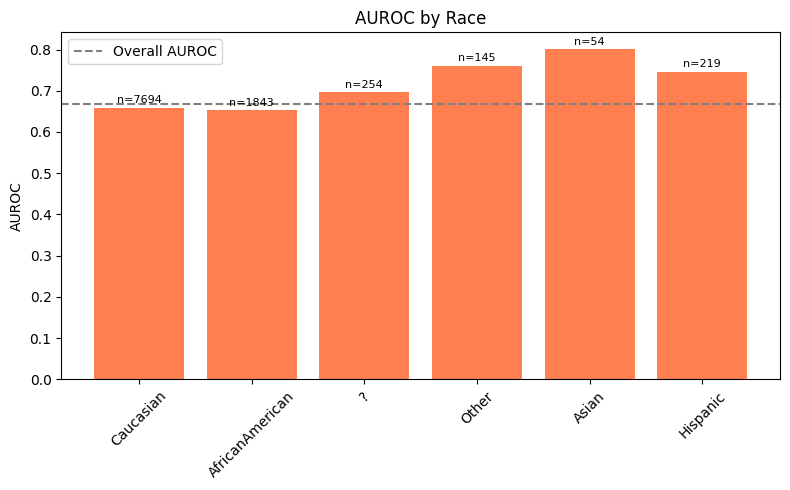

In [65]:
# Cell 46a - Purpose: Plot AUROC by race subgroup

data = fairness_results['race']
names = list(data.keys())
aurocs = [data[n]['auroc'] for n in names]
ns = [data[n]['n'] for n in names]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, aurocs, color='coral')
plt.axhline(y=final_comparison_df.iloc[0]['val_auroc'], color='gray', linestyle='--', label='Overall AUROC')
plt.title('AUROC by Race')
plt.ylabel('AUROC')
plt.xticks(rotation=45)
plt.legend()
for bar, n in zip(bars, ns):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'n={n}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('/kaggle/working/plots/fairness_race_auroc.png', dpi=150, bbox_inches='tight')
plt.show()

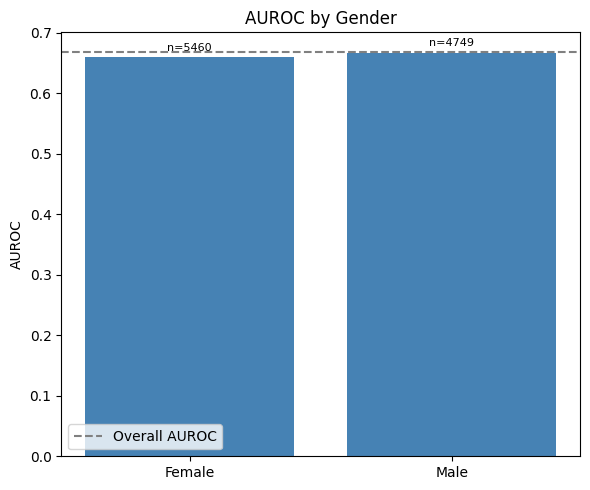

In [63]:
# Cell 46b - Purpose: Plot AUROC by gender subgroup

data = fairness_results['gender']
names = list(data.keys())
aurocs = [data[n]['auroc'] for n in names]
ns = [data[n]['n'] for n in names]

plt.figure(figsize=(6, 5))
bars = plt.bar(names, aurocs, color='steelblue')
plt.axhline(y=final_comparison_df.iloc[0]['val_auroc'], color='gray', linestyle='--', label='Overall AUROC')
plt.title('AUROC by Gender')
plt.ylabel('AUROC')
plt.legend()
for bar, n in zip(bars, ns):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'n={n}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('/kaggle/working/plots/fairness_gender_auroc.png', dpi=150, bbox_inches='tight')
plt.show()

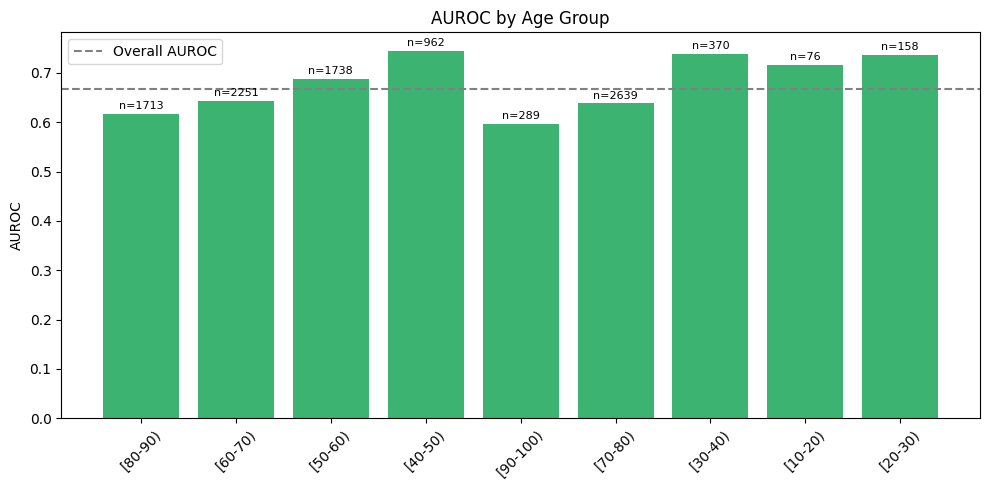

In [64]:
# Cell 46c - Purpose: Plot AUROC by age subgroup

data = fairness_results['age']
names = list(data.keys())
aurocs = [data[n]['auroc'] for n in names]
ns = [data[n]['n'] for n in names]

plt.figure(figsize=(10, 5))
bars = plt.bar(names, aurocs, color='mediumseagreen')
plt.axhline(y=final_comparison_df.iloc[0]['val_auroc'], color='gray', linestyle='--', label='Overall AUROC')
plt.title('AUROC by Age Group')
plt.ylabel('AUROC')
plt.xticks(rotation=45)
plt.legend()
for bar, n in zip(bars, ns):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'n={n}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('/kaggle/working/plots/fairness_age_auroc.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:

# Cell 48 - Purpose: Rebuild final zip archive including all newly added files

import zipfile

with zipfile.ZipFile('/kaggle/working/TrustMedX_deliverables.zip', 'w', zipfile.ZIP_DEFLATED) as zipf:
    for folder in ['results', 'plots', 'governance', 'manuscript']:
        folder_path = os.path.join('/kaggle/working', folder)
        if os.path.exists(folder_path):
            for root, dirs, files in os.walk(folder_path):
                for file in files:
                    file_path = os.path.join(root, file)
                    arcname = os.path.relpath(file_path, '/kaggle/working')
                    zipf.write(file_path, arcname)

print("Final zip rebuilt at: /kaggle/working/TrustMedX_deliverables.zip")
print("Size (MB):", os.path.getsize('/kaggle/working/TrustMedX_deliverables.zip') / (1024*1024))

print("\nContents:")
with zipfile.ZipFile('/kaggle/working/TrustMedX_deliverables.zip', 'r') as zipf:
    for name in zipf.namelist():
        print(" ", name)

Final zip rebuilt at: /kaggle/working/TrustMedX_deliverables.zip
Size (MB): 0.6784915924072266

Contents:
  results/results.json
  results/uq_summary.json
  results/model_comparison.csv
  results/shap_feature_importance.csv
  results/final_model_comparison.csv
  plots/fairness_subgroup_auroc.png
  plots/reliability_diagram.png
  plots/model_comparison_auroc.png
  plots/final_model_comparison.png
  plots/fairness_age_auroc.png
  plots/fairness_race_auroc.png
  plots/shap_waterfall_patient0.png
  plots/fairness_gender_auroc.png
  plots/shap_summary_plot.png
  plots/roc_curves_val.png
  governance/MODEL_CARD.md
  governance/DATA_CARD.md
  governance/DISCLAIMER.md
  manuscript/main.md
